In [1]:
import sys
sys.path.append('../')

In [20]:
pip install scikit-learn

  Using cached scipy-1.15.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 16.9 MB/s eta 0:00:000:00:0136m0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 30.8 MB/s eta 0:00:0031m31.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn]0m 3/4 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [21]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import pickle

import matplotlib.pyplot as plt
from gemininn import (
    data,
    learners,
    custom_loss,
    models,
    reports
)
from util import label_to_tuple, tuple_to_label



AUX_COLS = ["velocity","mass","deceleration_average"]
AUX_COLS_EXT = AUX_COLS  + [f'PCA_{i}' for i in range(10)]

NUM_LABELS = 4
NUM_CLASSES = 12

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [43]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)


metrics_labels = {
    'micro_f1': lambda y_true, y_pred, y_score: f1_score(
        y_true, y_pred, average='micro', zero_division=0
    ),
    'macro_f1': lambda y_true, y_pred, y_score: f1_score(
        y_true, y_pred, average='macro', zero_division=0
    ),
    'micro_precision': lambda y_true, y_pred, y_score: precision_score(
        y_true, y_pred, average='micro', zero_division=0
    ),
    'micro_recall': lambda y_true, y_pred, y_score: recall_score(
        y_true, y_pred, average='micro', zero_division=0
    ),
    'roc_auc_macro': lambda y_true, y_pred, y_score: roc_auc_score(
        y_true, y_score, average='macro'
    ),
    'roc_auc_micro': lambda y_true, y_pred, y_score: roc_auc_score(
        y_true, y_score, average='micro'
    )
}

In [23]:
with open("../data/half_cnngan.pickle", "rb") as f:
    half_cnngan = pickle.load(f)
with open("../data/half_mlpgan.pickle", "rb") as f:
    half_mlpgan = pickle.load(f)

In [25]:
def laberer(label):
    return np.array(label_to_tuple(label), dtype=np.int64)

In [31]:
with open("../data/test.pickle", "rb") as f:
    test = pickle.load(f)
X_test = test[[c for c in test.columns if c not in ('model', 'label')]]
y_test = test.label
X_half_cnngan = half_cnngan[[c for c in half_cnngan.columns if c not in ('model', 'label')]]
y_half_cnngan= half_cnngan.label
X_half_mlpgan = half_mlpgan[[c for c in half_mlpgan.columns if c not in ('model', 'label')]]
y_half_mlpgan = half_mlpgan.label

/var/folders/c6/jhfbvlfj0371f_3yzyzktxr00000gn/T/ipykernel_10696/3717256923.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  test = pickle.load(f)


In [72]:
X_test.mass = X_test.mass.fillna(X_half_cnngan.mass.mean())

/var/folders/c6/jhfbvlfj0371f_3yzyzktxr00000gn/T/ipykernel_10696/2360943389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.mass = X_test.mass.fillna(X_half_cnngan.mass.mean())


In [34]:
y_half_cnngan_v = np.vstack(y_half_cnngan.apply(laberer).values)
y_half_mlpgan_v = np.vstack(y_half_mlpgan.apply(laberer).values)
y_test_v = np.vstack(y_test.apply(laberer).values)

In [62]:
from sklearn.model_selection import train_test_split

# CNN-GAN split
X_half_cnngan_ttrain, X_half_cnngan_val, \
X_half_mlpgan_ttrain, X_half_mlpgan_val, \
y_half_cnngan_ttrain, y_half_cnngan_val = train_test_split(
    X_half_cnngan,
    X_half_mlpgan,
    y_half_cnngan_v,
    test_size=0.2,
    stratify=y_half_cnngan_v  # if you want to preserve class proportions
)



In [73]:
loaders_half_cnngan= data.build_all_loaders(X_half_cnngan_ttrain, y_half_cnngan_ttrain,
                                       X_half_cnngan_val, y_half_cnngan_val,
                                       X_test, y_test_v,
                                       sensor_key='sensor_data', 
                                       pers_key='sensor_data',
                                       aux_cols=AUX_COLS, 
                                       ext_aux_cols=AUX_COLS)

loaders_half_half_mlpgan = data.build_all_loaders(X_half_mlpgan_ttrain, y_half_mlpgan_ttrain,
                                       X_half_mlpgan_val, y_half_mlpgan_val,
                                       X_test, y_test_v,
                                       sensor_key='sensor_data', 
                                       pers_key='sensor_data',
                                       aux_cols=AUX_COLS, 
                                       ext_aux_cols=AUX_COLS)

In [65]:
all_labels = torch.cat([labs for _, labs in loaders_half_cnngan['train']]).float()
pos_cnt    = all_labels.sum(0)
neg_cnt    = len(all_labels) - pos_cnt
pos_weight = (neg_cnt / (pos_cnt+1e-5)).to(device)

In [84]:
simple_cnn_model = models.ConfigurableTwoBranchCNN(
     num_aux_feats=len(AUX_COLS),
     num_labels=NUM_LABELS,
     conv_channels=[32, 64, 128],
     pool_sizes=[(2,2), (2,2), (2,1)],
     sensor_shape=(128, 6),
     in_channels=1)

In [85]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(simple_cnn_model.parameters(),
                      lr=1e-5,
                      weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 patience=2,
                                                 cooldown=2,
                                                 min_lr=1e-10,
                                                 factor=0.2)

simple_cnn = learners.MultiLabelLearner(simple_cnn_model,
                                        optimizer,
                                        criterion,
                                        loaders_half_cnngan['train'],
                                        loaders_half_cnngan['val'],
                                        metrics=metrics_labels,
                                        scheduler=scheduler,
                                        model_name='SimpleCNNStandartData')

In [86]:
history_simple_cnn = simple_cnn.fit(500)

### Starting SimpleCNNStandartData_solar_horizon_20250618_223512
  model: ConfigurableTwoBranchCNN
  optimizer: Adam
  criterion: BCEWithLogitsLoss
  scheduler: ReduceLROnPlateau
  patience: 10
  metrics: ['micro_f1', 'macro_f1', 'micro_precision', 'micro_recall', 'roc_auc_macro', 'roc_auc_micro']
Epoch 001 — loss 3.9963/1.1033 — lr 1.0e-05
                                              micro_f1       :  0.0000 | macro_f1       :  0.0000 | micro_precision:  0.0000
                                              micro_recall   :  0.0000 | roc_auc_macro  :  0.6060 | roc_auc_micro  :  0.5367
Epoch 002 — loss 2.6056/0.9411 — lr 1.0e-05
                                              micro_f1       :  0.0000 | macro_f1       :  0.0000 | micro_precision:  0.0000
                                              micro_recall   :  0.0000 | roc_auc_macro  :  0.7023 | roc_auc_micro  :  0.5691
Epoch 003 — loss 1.7797/0.6861 — lr 1.0e-05
                                              micro_f1       :  0.000

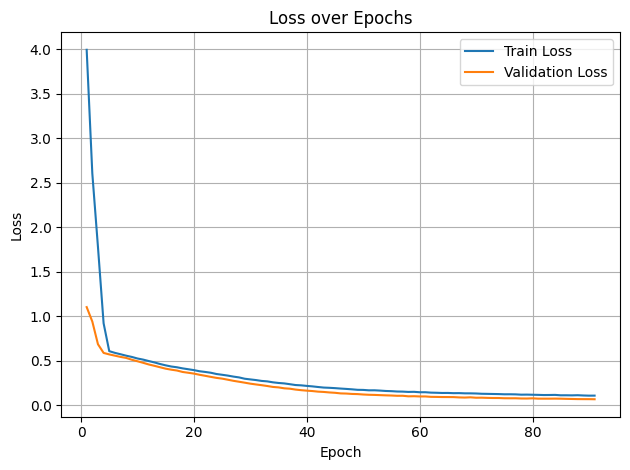

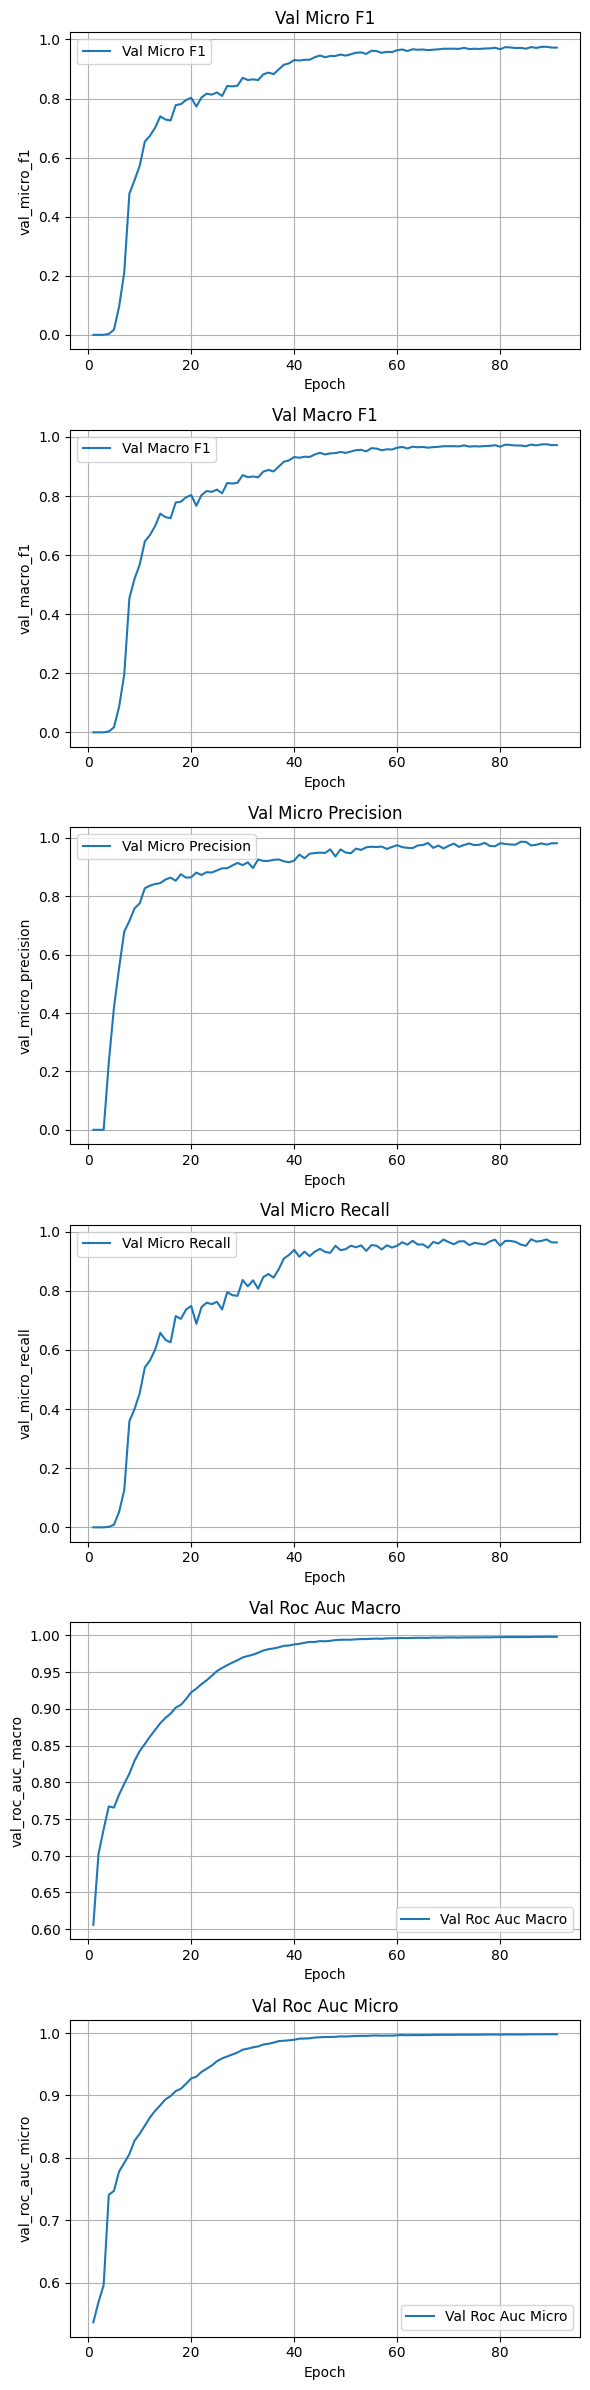

In [87]:
reports.plot_history(history_simple_cnn)

In [88]:
y_true, y_pred, y_score = reports.predict_multilabel(simple_cnn_model, loaders_half_cnngan['test'])

=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.10      0.56      0.17       103
           1       0.21      0.55      0.31        96
           2       0.25      0.44      0.32       104
           3       0.28      0.41      0.33       105

   micro avg       0.17      0.49      0.26       408
   macro avg       0.21      0.49      0.28       408
weighted avg       0.21      0.49      0.28       408
 samples avg       0.13      0.20      0.15       408



/opt/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

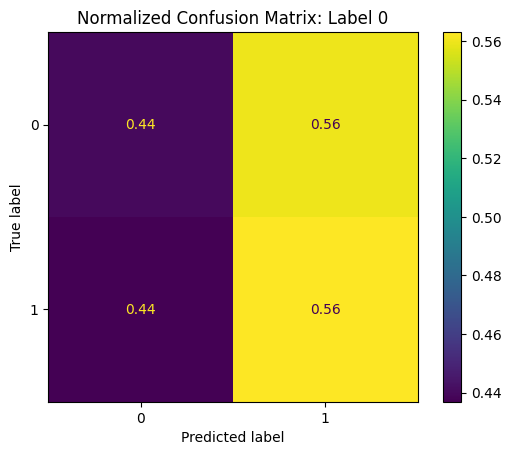

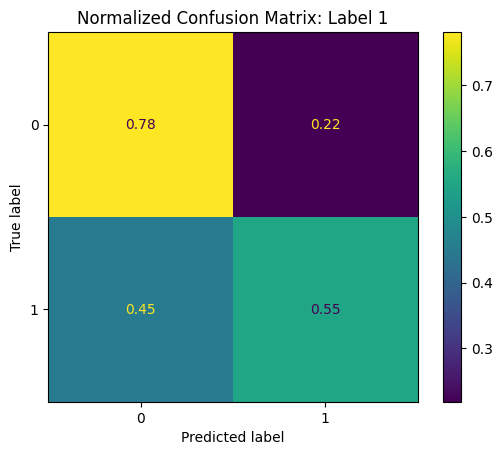

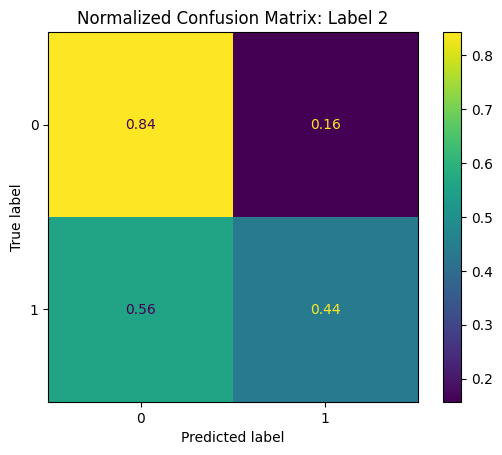

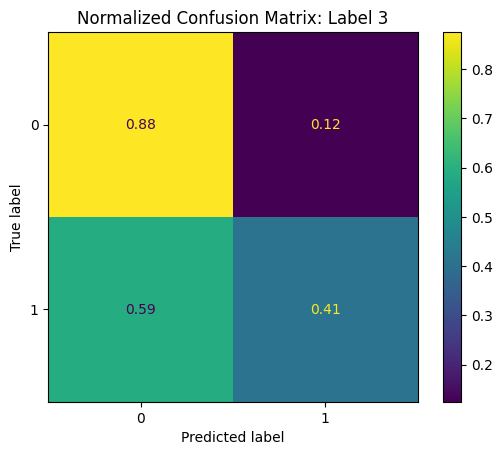

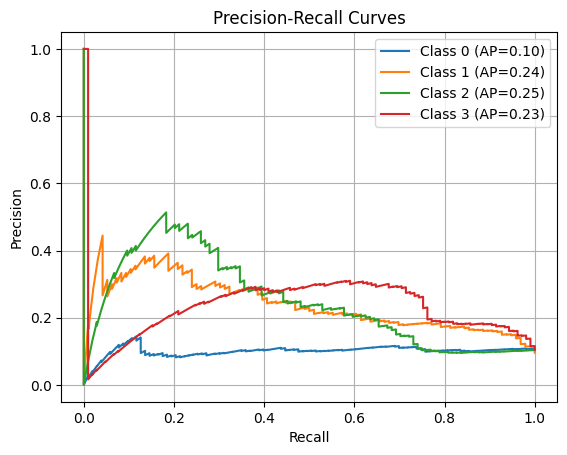

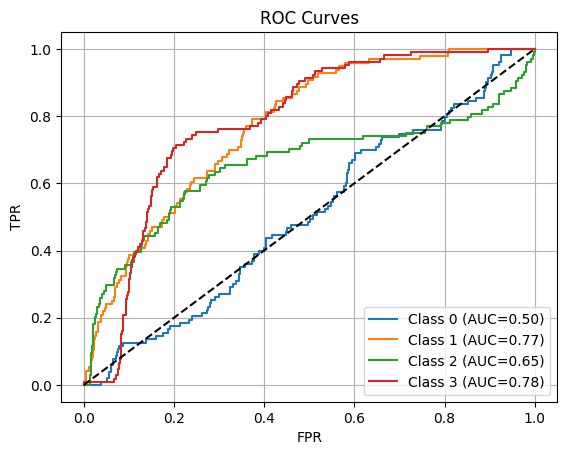

              precision    recall  f1-score   support

    negative       0.64      0.31      0.42       593
    positive       0.43      0.75      0.54       408

    accuracy                           0.49      1001
   macro avg       0.53      0.53      0.48      1001
weighted avg       0.55      0.49      0.47      1001



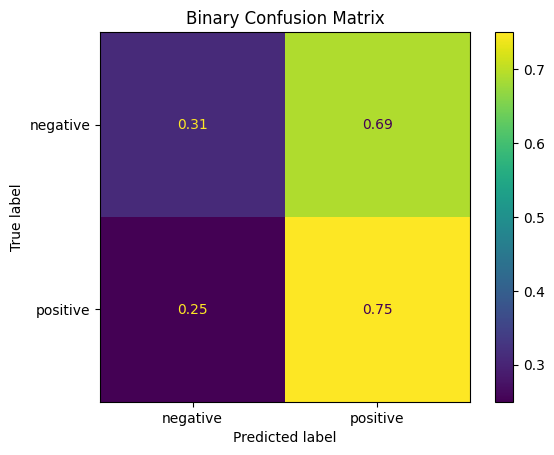

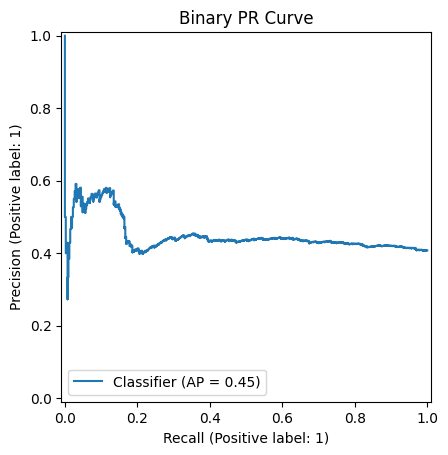

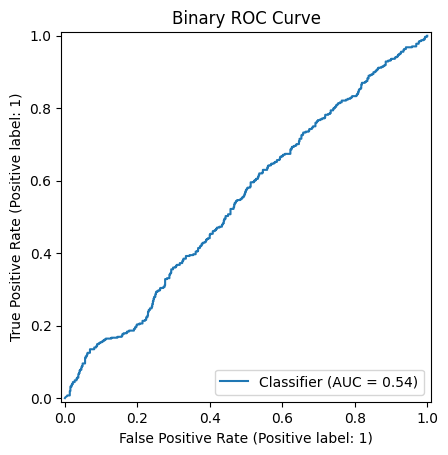

In [89]:
reports.full_report_multilabel(y_true, y_pred, y_score, plot=True);

In [93]:
simple_cnn_model = models.ConfigurableTwoBranchCNN(
     num_aux_feats=len(AUX_COLS),
     num_labels=NUM_LABELS,
     conv_channels=[32, 64, 128],
     pool_sizes=[(2,2), (2,2), (2,1)],
     sensor_shape=(128, 6),
     in_channels=1)

In [94]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(simple_cnn_model.parameters(),
                      lr=1e-5,
                      weight_decay=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                 patience=2,
                                                 cooldown=2,
                                                 min_lr=1e-10,
                                                 factor=0.2)

simple_cnn = learners.MultiLabelLearner(simple_cnn_model,
                                        optimizer,
                                        criterion,
                                        loaders_half_half_mlpgan['train'],
                                        loaders_half_half_mlpgan['val'],
                                        metrics=metrics_labels,
                                        scheduler=scheduler,
                                        model_name='SimpleCNNStandartData')

In [95]:
history_simple_cnn = simple_cnn.fit(500)

### Starting SimpleCNNStandartData_crimson_rider_20250618_224650
  model: ConfigurableTwoBranchCNN
  optimizer: Adam
  criterion: BCEWithLogitsLoss
  scheduler: ReduceLROnPlateau
  patience: 10
  metrics: ['micro_f1', 'macro_f1', 'micro_precision', 'micro_recall', 'roc_auc_macro', 'roc_auc_micro']
Epoch 001 — loss 4.7978/1.2661 — lr 1.0e-05
                                              micro_f1       :  0.0000 | macro_f1       :  0.0000 | micro_precision:  0.0000
                                              micro_recall   :  0.0000 | roc_auc_macro  :  0.4994 | roc_auc_micro  :  0.4975
Epoch 002 — loss 2.9344/1.0564 — lr 1.0e-05
                                              micro_f1       :  0.0000 | macro_f1       :  0.0000 | micro_precision:  0.0000
                                              micro_recall   :  0.0000 | roc_auc_macro  :  0.4981 | roc_auc_micro  :  0.5040
Epoch 003 — loss 2.0261/0.7812 — lr 1.0e-05
                                              micro_f1       :  0.000

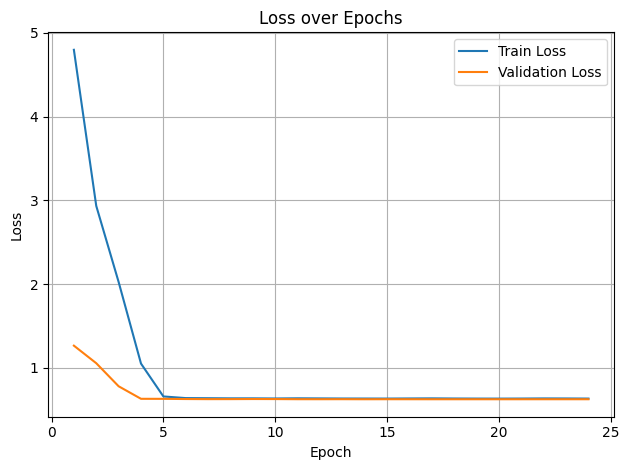

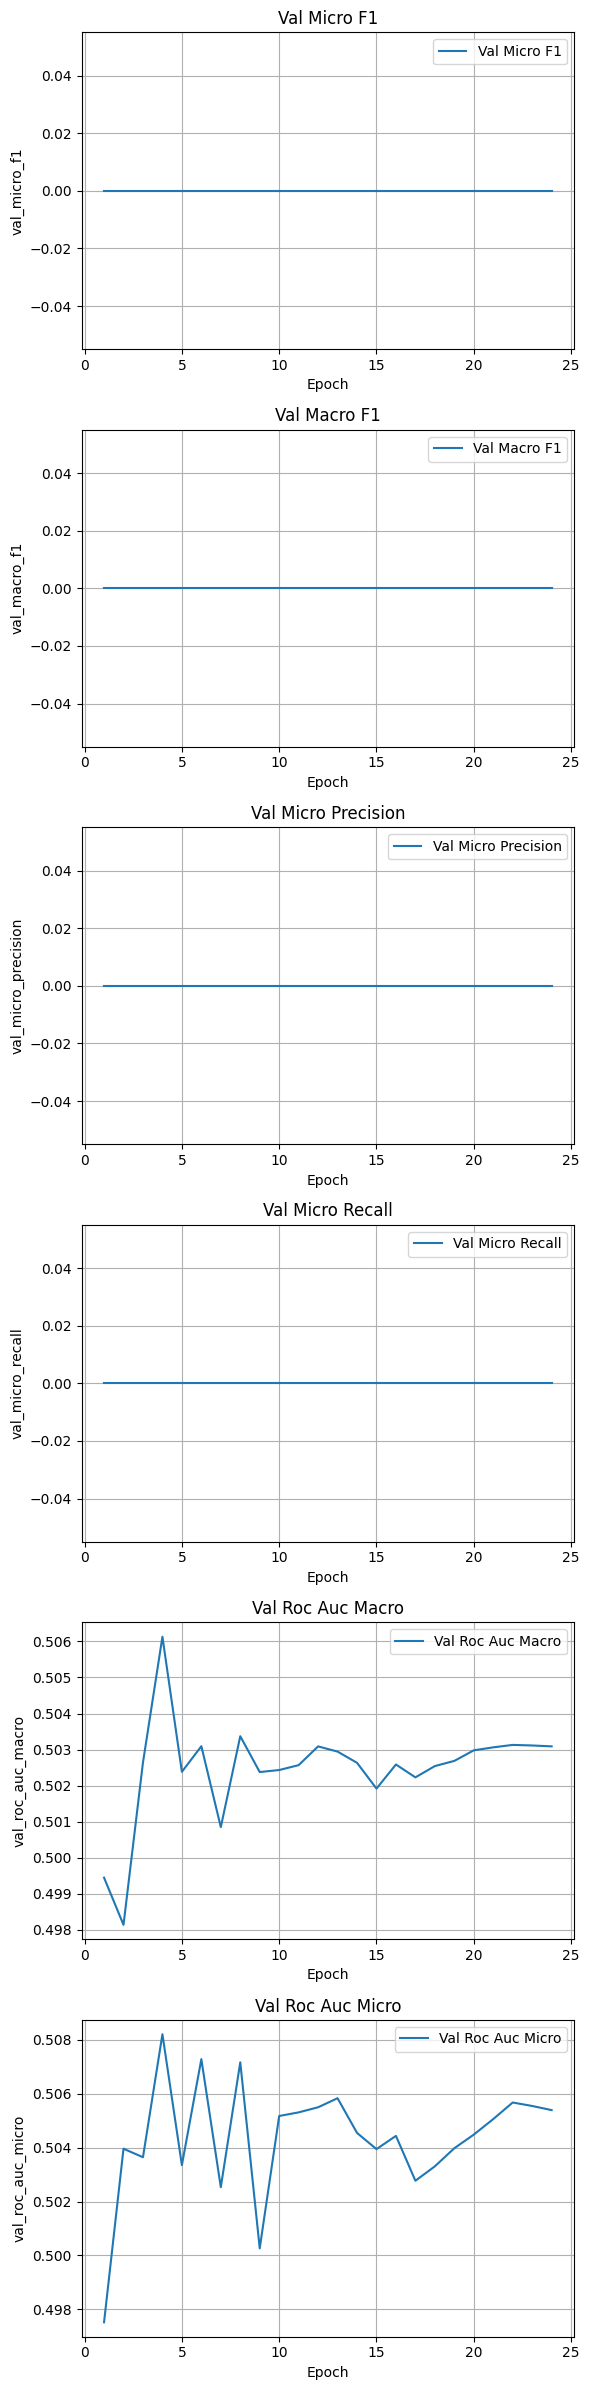

In [96]:
reports.plot_history(history_simple_cnn)

In [88]:
y_true, y_pred, y_score = reports.predict_multilabel(simple_cnn_model, loaders_half_cnngan['test'])

=== Multilabel Classification Report ===
              precision    recall  f1-score   support

           0       0.10      0.56      0.17       103
           1       0.21      0.55      0.31        96
           2       0.25      0.44      0.32       104
           3       0.28      0.41      0.33       105

   micro avg       0.17      0.49      0.26       408
   macro avg       0.21      0.49      0.28       408
weighted avg       0.21      0.49      0.28       408
 samples avg       0.13      0.20      0.15       408



/opt/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/jupyter_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

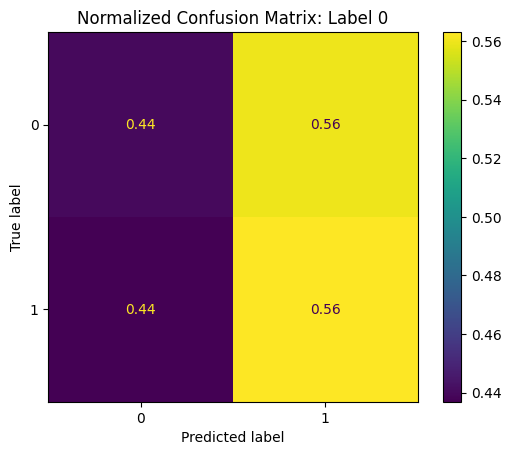

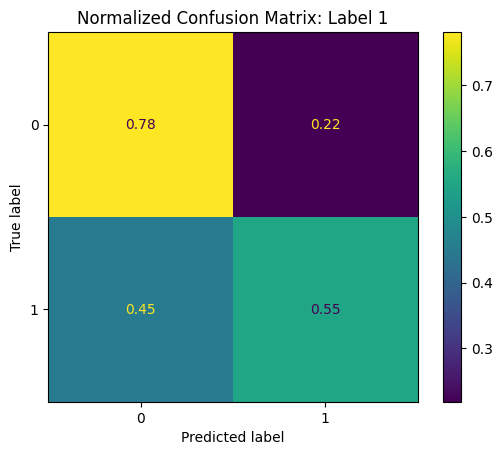

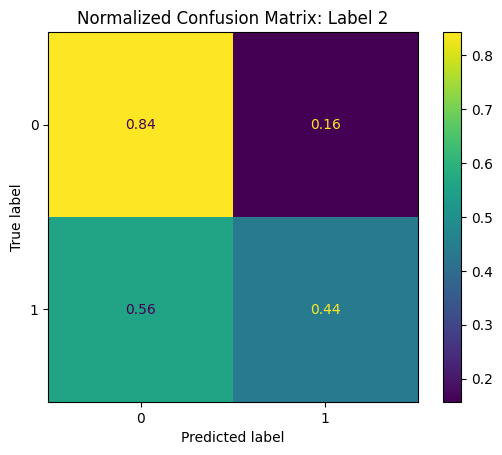

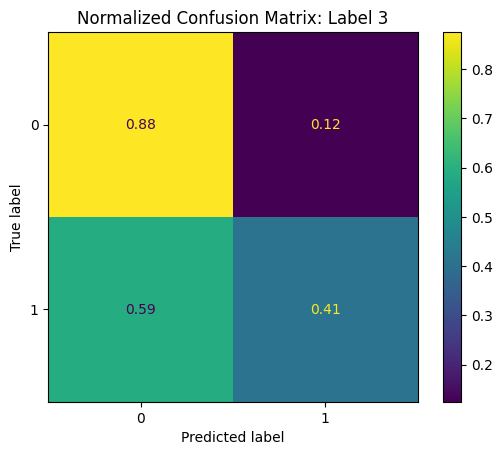

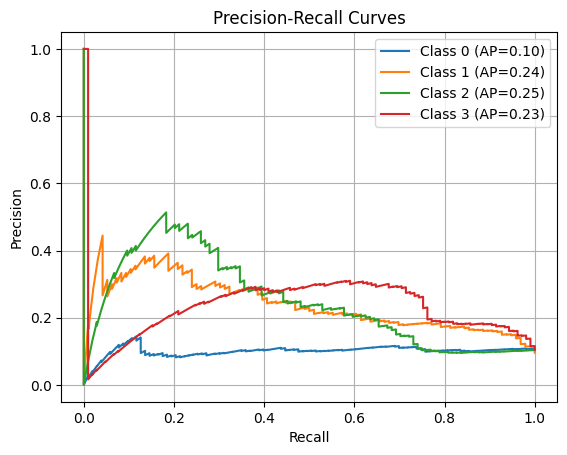

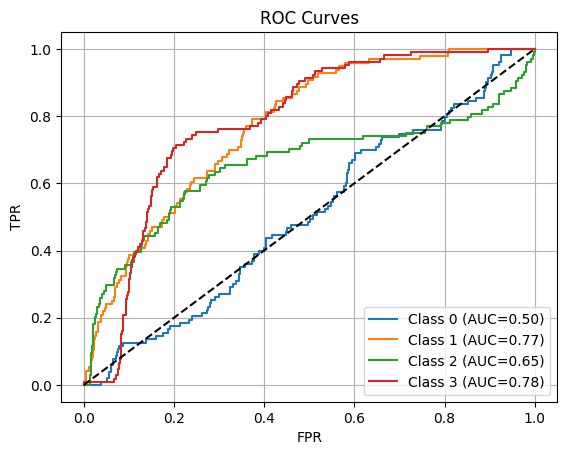

              precision    recall  f1-score   support

    negative       0.64      0.31      0.42       593
    positive       0.43      0.75      0.54       408

    accuracy                           0.49      1001
   macro avg       0.53      0.53      0.48      1001
weighted avg       0.55      0.49      0.47      1001



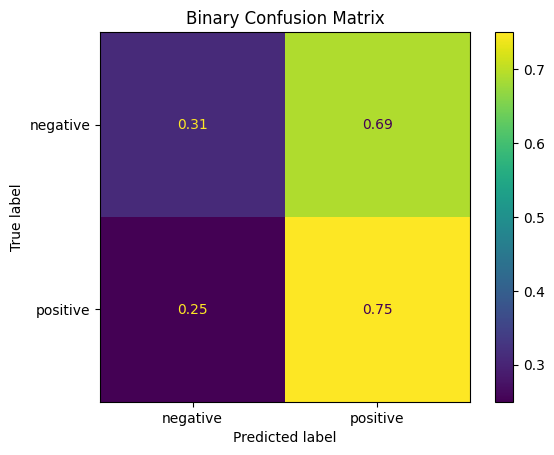

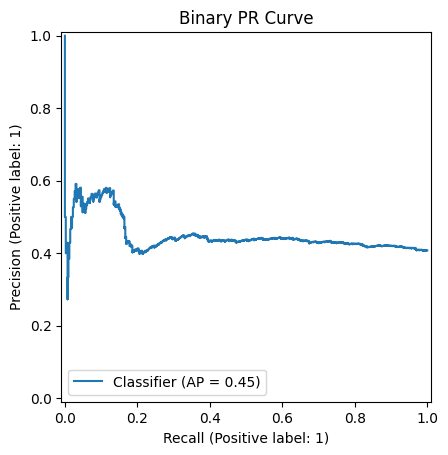

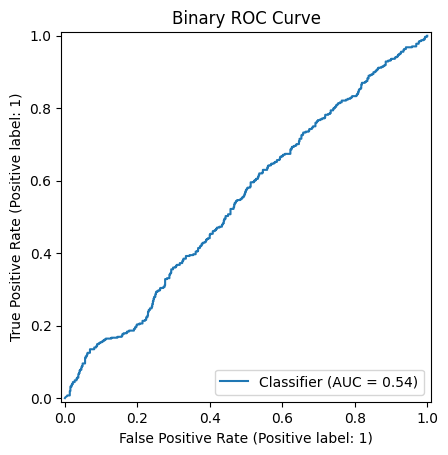

In [89]:
reports.full_report_multilabel(y_true, y_pred, y_score, plot=True);

In [58]:
y_score.sum()

np.float32(nan)